<a href="https://colab.research.google.com/github/azizy-123/AI_Projects/blob/main/Fashion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Visualizing sample images...


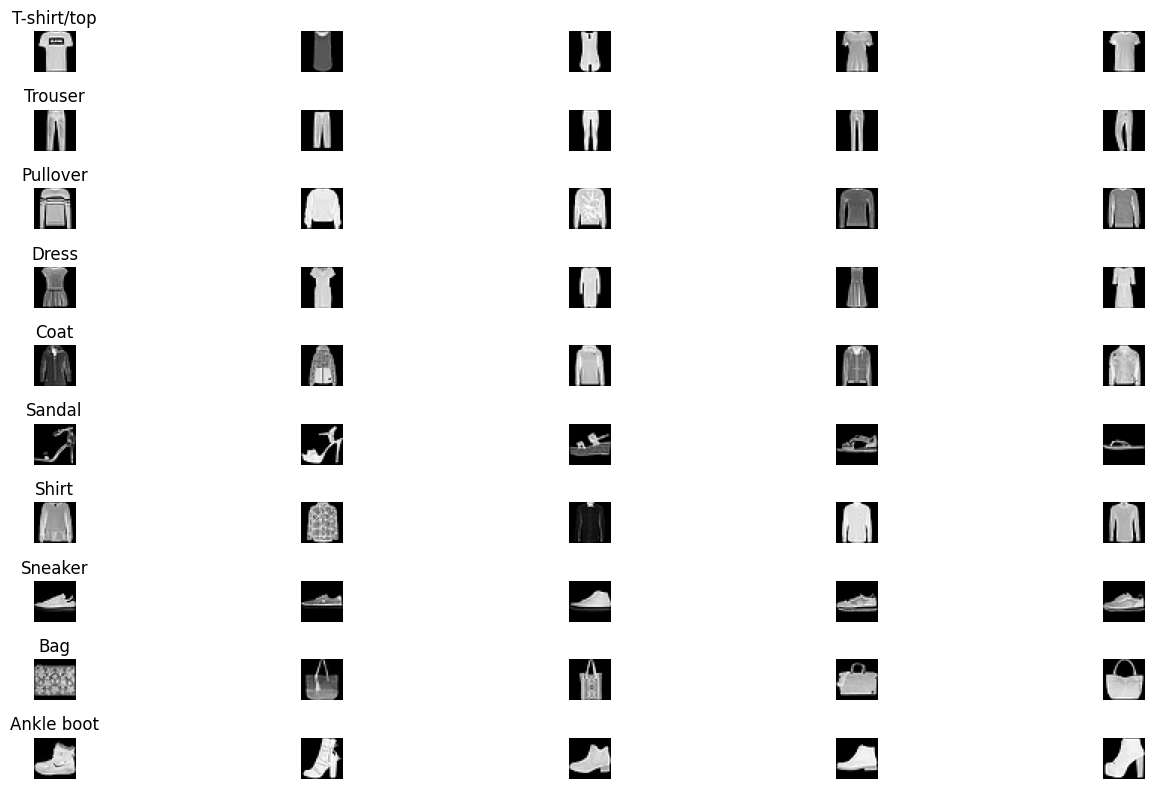


Running KNN Classification...


KNN Progress: 100%|██████████| 1000/1000 [00:42<00:00, 23.51it/s]



KNN Results:
Accuracy: 0.827

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.69      0.85      0.76       107
     Trouser       0.98      0.96      0.97       105
    Pullover       0.72      0.80      0.76       111
       Dress       0.87      0.77      0.82        93
        Coat       0.82      0.73      0.77       115
      Sandal       0.96      0.83      0.89        87
       Shirt       0.60      0.55      0.57        97
     Sneaker       0.88      0.89      0.89        95
         Bag       0.99      0.94      0.96        95
  Ankle boot       0.86      0.96      0.91        95

    accuracy                           0.83      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



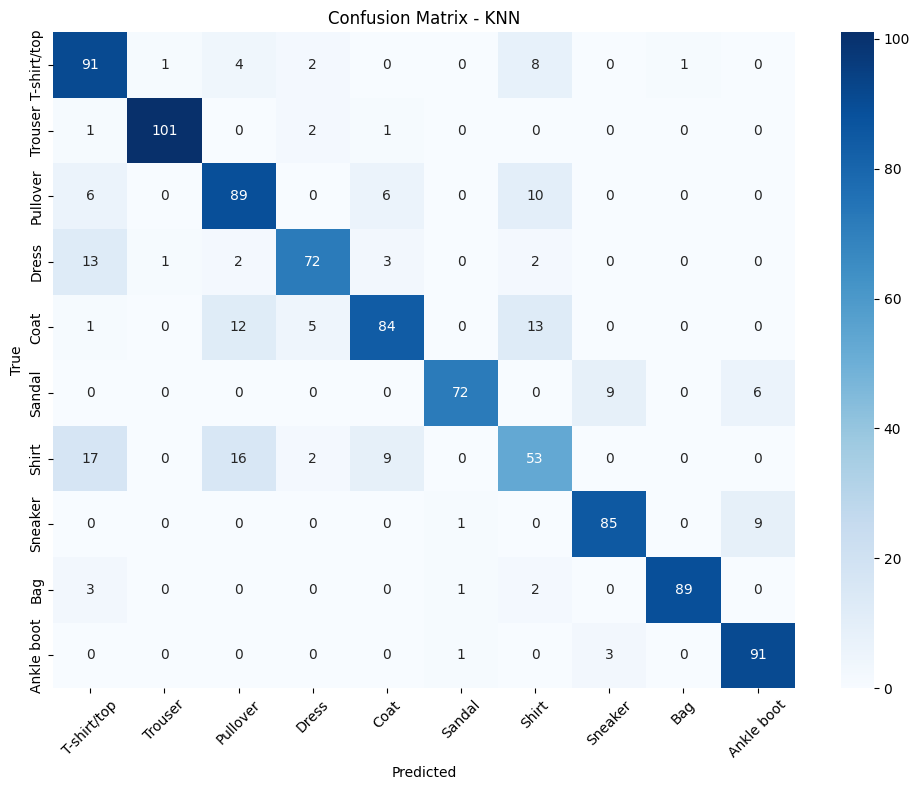


Running Binary Logistic Regression...

Logistic Regression (Binary) Results:
Accuracy: 0.9811320754716981

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.98      0.98      0.98       107
     Trouser       0.98      0.98      0.98       105

    accuracy                           0.98       212
   macro avg       0.98      0.98      0.98       212
weighted avg       0.98      0.98      0.98       212



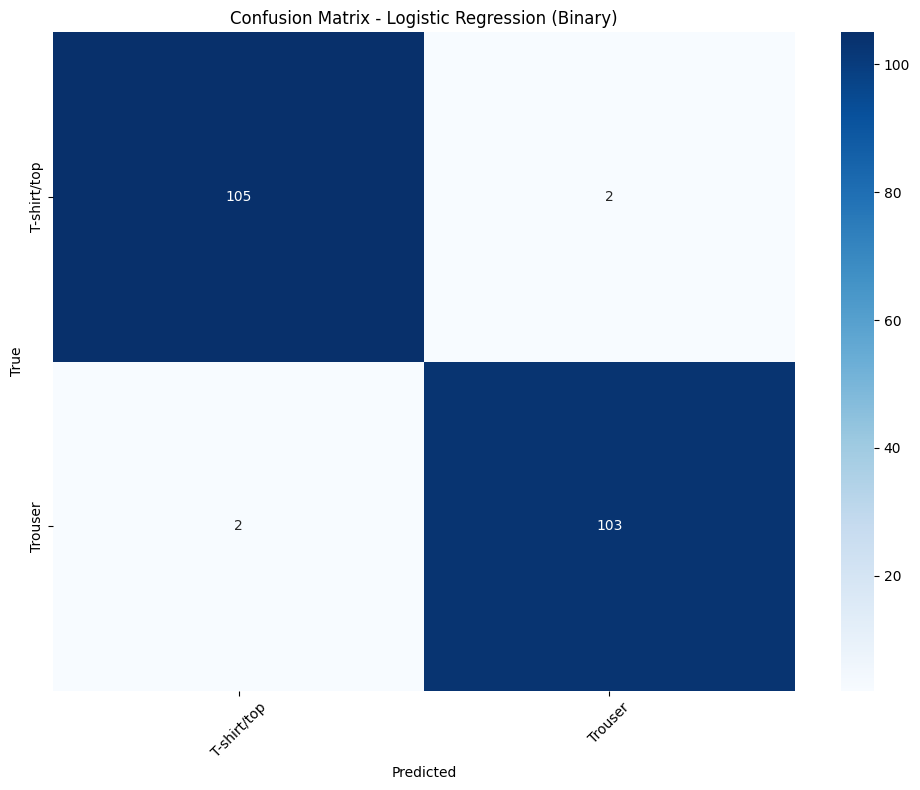


Running Softmax Regression...

Softmax Regression Results:
Accuracy: 0.771

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.82      0.81       107
     Trouser       0.96      0.92      0.94       105
    Pullover       0.73      0.67      0.69       111
       Dress       0.75      0.84      0.79        93
        Coat       0.64      0.74      0.69       115
      Sandal       0.95      0.60      0.73        87
       Shirt       0.52      0.39      0.45        97
     Sneaker       0.74      0.85      0.79        95
         Bag       0.90      0.95      0.92        95
  Ankle boot       0.79      0.93      0.85        95

    accuracy                           0.77      1000
   macro avg       0.78      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



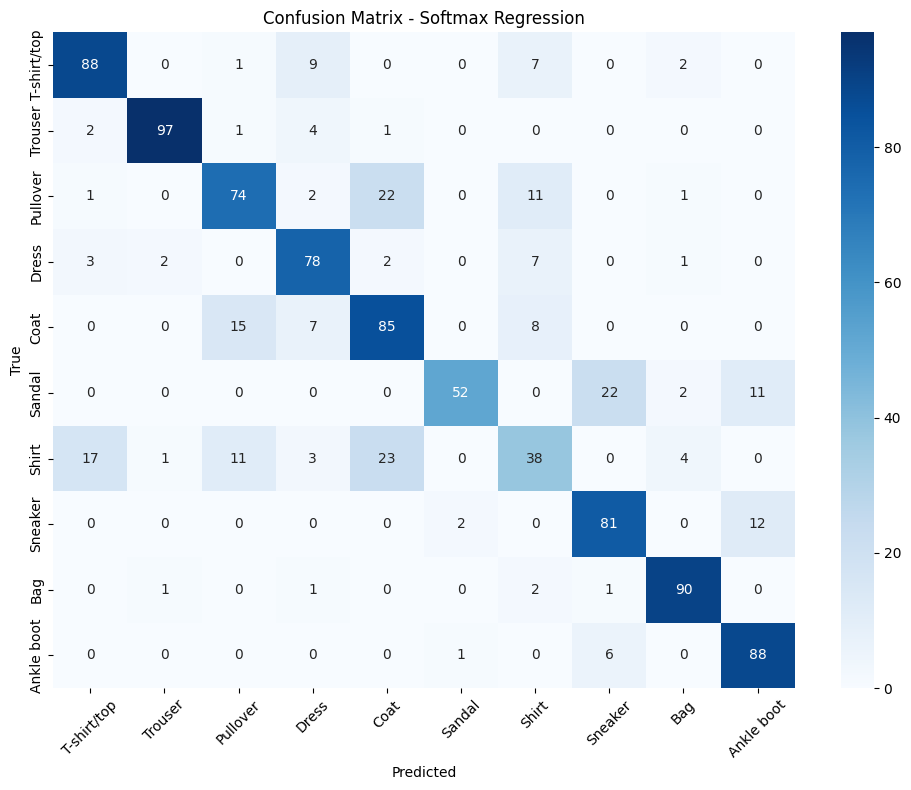


Running SVM Classification with RBF Kernel...

SVM with RBF Kernel Results:
Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.81      0.83       107
     Trouser       0.98      0.95      0.97       105
    Pullover       0.74      0.83      0.78       111
       Dress       0.78      0.86      0.82        93
        Coat       0.88      0.79      0.83       115
      Sandal       0.93      0.91      0.92        87
       Shirt       0.68      0.64      0.66        97
     Sneaker       0.91      0.96      0.93        95
         Bag       0.92      0.96      0.94        95
  Ankle boot       0.97      0.92      0.94        95

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



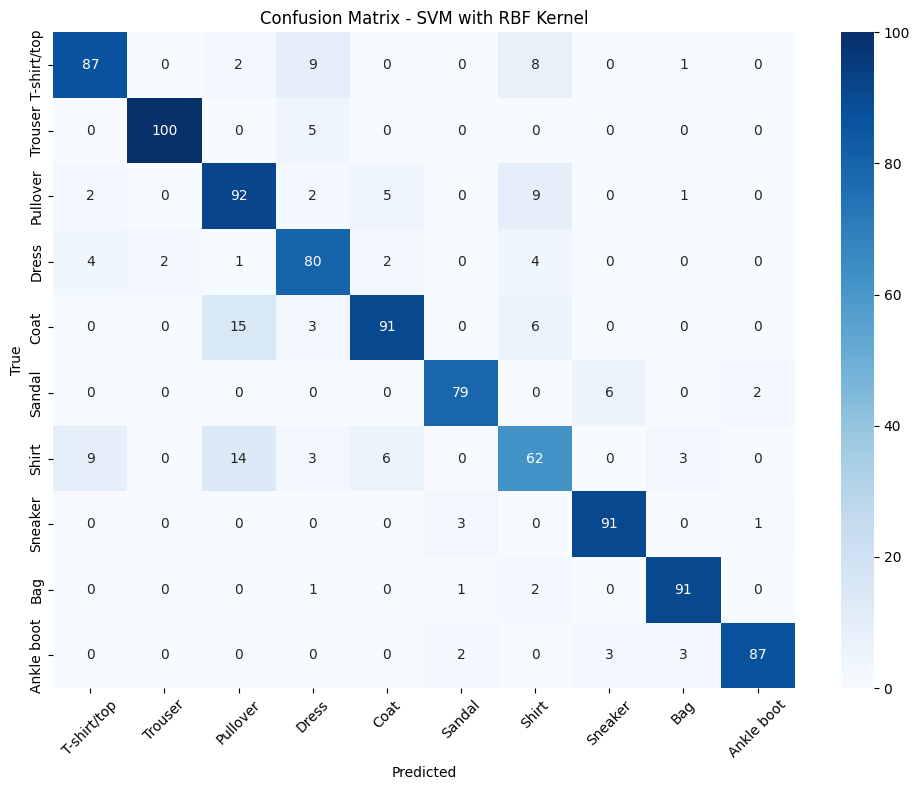


Running SVM Classification with Linear Kernel...

SVM with Linear Kernel Results:
Accuracy: 0.806

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.80      0.80       107
     Trouser       0.93      0.97      0.95       105
    Pullover       0.61      0.69      0.65       111
       Dress       0.77      0.75      0.76        93
        Coat       0.75      0.68      0.71       115
      Sandal       0.92      0.92      0.92        87
       Shirt       0.52      0.49      0.51        97
     Sneaker       0.90      0.91      0.90        95
         Bag       1.00      0.96      0.98        95
  Ankle boot       0.94      0.93      0.93        95

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



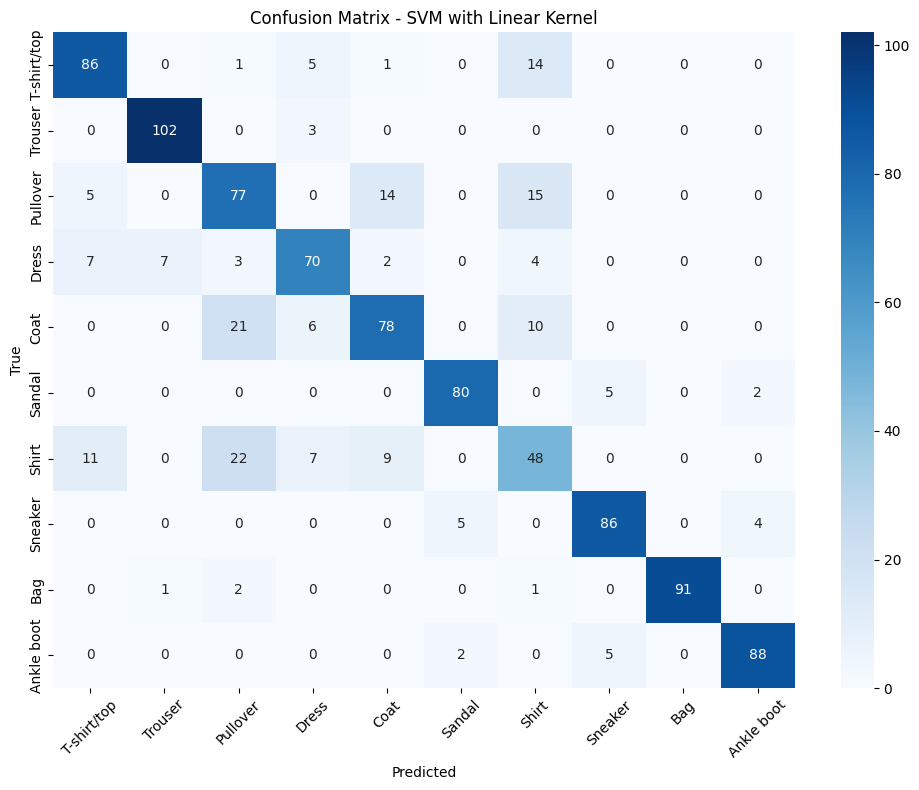

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages


class FashionClassifier:
    def __init__(self):
        # Class labels for Fashion MNIST
        self.class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
        self.load_data()

    def load_data(self):
        """Load and preprocess Fashion MNIST dataset"""
        # Load data
        (self.X_train, self.y_train), (self.X_test, self.y_test) = fashion_mnist.load_data()

        # Reshape and normalize data
        self.X_train = self.X_train.reshape(self.X_train.shape[0], -1) / 255.0
        self.X_test = self.X_test.reshape(self.X_test.shape[0], -1) / 255.0

        # Take a subset for faster training during development
        self.X_train = self.X_train[:10000]
        self.y_train = self.y_train[:10000]
        self.X_test = self.X_test[:1000]
        self.y_test = self.y_test[:1000]

    def visualize_samples(self, num_samples=5):
        """Visualize sample images from each class"""
        plt.figure(figsize=(15, 8))
        for class_idx in range(10):
            for sample_idx in range(num_samples):
                plt.subplot(10, num_samples, class_idx * num_samples + sample_idx + 1)
                plt.imshow(self.X_train[self.y_train == class_idx][sample_idx].reshape(28, 28),
                          cmap='gray')
                plt.axis('off')
                if sample_idx == 0:
                    plt.title(self.class_names[class_idx])
        plt.tight_layout()
        plt.show()

    class KNNClassifier:
        def __init__(self, k=3):
            self.k = k
            self.X_train = None
            self.y_train = None

        def fit(self, X, y):
            self.X_train = X
            self.y_train = y

        def predict(self, X):
            predictions = []
            for x in tqdm(X, desc="KNN Progress"):
                distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
                k_indices = np.argsort(distances)[:self.k]
                k_nearest_labels = self.y_train[k_indices]
                prediction = np.bincount(k_nearest_labels).argmax()
                predictions.append(prediction)
            return np.array(predictions)

    class LogisticRegression:
        def __init__(self, learning_rate=0.1, num_iterations=100):
            self.learning_rate = learning_rate
            self.num_iterations = num_iterations
            self.weights = None
            self.bias = None

        def sigmoid(self, z):
            return 1 / (1 + np.exp(-z))

        def fit(self, X, y, binary_classes=(0, 1)):
            mask = np.isin(y, binary_classes)
            X = X[mask]
            y = y[mask]
            y = (y == binary_classes[1]).astype(int)

            self.weights = np.zeros(X.shape[1])
            self.bias = 0

            for _ in range(self.num_iterations):
                z = np.dot(X, self.weights) + self.bias
                predictions = self.sigmoid(z)

                dz = predictions - y
                dw = np.dot(X.T, dz) / len(y)
                db = np.sum(dz) / len(y)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

        def predict(self, X):
            z = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(z)
            return (predictions >= 0.5).astype(int)

    class SoftmaxRegression:
        def __init__(self, learning_rate=0.1, num_iterations=100):
            self.learning_rate = learning_rate
            self.num_iterations = num_iterations
            self.weights = None
            self.bias = None

        def softmax(self, z):
            exp = np.exp(z - np.max(z, axis=1, keepdims=True))
            return exp / np.sum(exp, axis=1, keepdims=True)

        def fit(self, X, y):
            num_classes = len(np.unique(y))
            self.weights = np.zeros((X.shape[1], num_classes))
            self.bias = np.zeros(num_classes)

            # One-hot encode labels
            y_onehot = np.zeros((len(y), num_classes))
            y_onehot[np.arange(len(y)), y] = 1

            for _ in range(self.num_iterations):
                z = np.dot(X, self.weights) + self.bias
                predictions = self.softmax(z)

                error = predictions - y_onehot
                dw = np.dot(X.T, error) / len(y)
                db = np.sum(error, axis=0) / len(y)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

        def predict(self, X):
            z = np.dot(X, self.weights) + self.bias
            return np.argmax(self.softmax(z), axis=1)

    class SVMClassifier:
        def __init__(self, kernel='rbf', C=1.0, gamma='scale'):
           self.kernel = kernel
           self.C = C
           self.gamma = gamma
           self.model = None
           self.scaler = None

        def fit(self, X, y):
            self.scaler = StandardScaler()
            X_scaled = self.scaler.fit_transform(X)

            self.model = SVC(kernel=self.kernel, C=self.C, gamma=self.gamma)
            self.model.fit(X_scaled, y)

        def predict(self, X):
            X_scaled = self.scaler.transform(X)
            return self.model.predict(X_scaled)


    def evaluate_model(self, y_true, y_pred, model_name, lr=False):
        """Evaluate model performance and display metrics"""
        print(f"\n{model_name} Results:")
        print("Accuracy:", accuracy_score(y_true, y_pred))
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, target_names=self.class_names if not lr else self.lrClasses))

        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.class_names if not lr else self.lrClasses,
                   yticklabels=self.class_names if not lr else self.lrClasses)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def run_experiments(self):
        """Run all classification experiments"""
        # 1. KNN Classification
        print("\nRunning KNN Classification...")
        knn = self.KNNClassifier(k=3)
        knn.fit(self.X_train, self.y_train)
        knn_predictions = knn.predict(self.X_test)
        self.evaluate_model(self.y_test, knn_predictions, "KNN")

        # 2. Binary Logistic Regression (T-shirt vs. Trouser)
        print("\nRunning Binary Logistic Regression...")
        log_reg = self.LogisticRegression(learning_rate=0.1, num_iterations=100)
        binary_classes = (0, 1)
        self.lrClasses = [self.class_names[cls] for cls in binary_classes]
        log_reg.fit(self.X_train, self.y_train, binary_classes)
        # Evaluate only on test samples from the two classes
        test_mask = np.isin(self.y_test, binary_classes)
        log_reg_predictions = log_reg.predict(self.X_test[test_mask])
        self.evaluate_model(self.y_test[test_mask], log_reg_predictions, "Logistic Regression (Binary)", True)

        # 3. Softmax Regression
        print("\nRunning Softmax Regression...")
        softmax = self.SoftmaxRegression(learning_rate=0.1, num_iterations=100)
        softmax.fit(self.X_train, self.y_train)
        softmax_predictions = softmax.predict(self.X_test)
        self.evaluate_model(self.y_test, softmax_predictions, "Softmax Regression")

        # 4. SVM with RBF kernel
        print("\nRunning SVM Classification with RBF Kernel...")
        svm_rbf = self.SVMClassifier(kernel='rbf', C=1.0, gamma='scale')
        svm_rbf.fit(self.X_train, self.y_train)
        svm_rbf_predictions = svm_rbf.predict(self.X_test)
        self.evaluate_model(self.y_test, svm_rbf_predictions, "SVM with RBF Kernel")

        # 5. SVM with linear kernel
        print("\nRunning SVM Classification with Linear Kernel...")
        svm_linear = self.SVMClassifier(kernel='linear', C=1.0, gamma='scale')
        svm_linear.fit(self.X_train, self.y_train)
        svm_linear_predictions = svm_linear.predict(self.X_test)
        self.evaluate_model(self.y_test, svm_linear_predictions, "SVM with Linear Kernel")


if __name__ == "__main__":
    # Initialize and run the fashion classifier
    classifier = FashionClassifier()

    # Visualize sample images
    print("Visualizing sample images...")
    classifier.visualize_samples()

    # Run all experiments
    classifier.run_experiments()